# Proyek Klasifikasi Gambar: Intel Image Classification
- **Nama:** Muhammad Ragil
- **Email:** mhmmdragilpy
- **ID Dicoding:** mhmmdragilpy

## Import Semua Packages/Library yang Digunakan

In [2]:
!nvidia-smi 2>/dev/null || echo 'GPU belum aktif. Aktifkan via Runtime > Change runtime type > T4 GPU'
!pip install -q split-folders pipreqs
!pip install -q tensorflowjs --no-deps

Mon Aug 24 08:07:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
import splitfolders

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow Version: {tf.__version__}')
print(f'GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow Version: 2.20.0
GPU Available: True


## Data Preparation

### Data Loading

In [4]:
# Download dan ekstrak dataset dari Kaggle
dataset_zip = 'intel-image-classification.zip'
dataset_dir = 'dataset'

if not os.path.exists(dataset_dir):
    if not os.path.exists(dataset_zip):
        !curl -L -o intel-image-classification.zip https://www.kaggle.com/api/v1/datasets/download/puneet6060/intel-image-classification
    with zipfile.ZipFile(dataset_zip, 'r') as z:
        z.extractall(dataset_dir)
    print('Dataset berhasil diekstrak.')
else:
    print('Dataset sudah tersedia.')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  346M  100  346M    0     0  19.4M      0  0:00:17  0:00:17 --:--:-- 21.4M
Dataset berhasil diekstrak.


In [5]:
# Gabungkan seg_train dan seg_test ke satu direktori untuk di-split ulang
raw_dir = 'raw_combined'
classes = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

for cls in classes:
    os.makedirs(os.path.join(raw_dir, cls), exist_ok=True)

for src in [os.path.join(dataset_dir, 'seg_train', 'seg_train'),
            os.path.join(dataset_dir, 'seg_test', 'seg_test')]:
    if os.path.exists(src):
        for cls in classes:
            s = os.path.join(src, cls)
            d = os.path.join(raw_dir, cls)
            if os.path.exists(s):
                for f in os.listdir(s):
                    if not os.path.exists(os.path.join(d, f)):
                        shutil.copy2(os.path.join(s, f), os.path.join(d, f))

# Verifikasi jumlah gambar dan variasi resolusi asli
resolutions = set()
total = 0
for cls in classes:
    files = [f for f in os.listdir(os.path.join(raw_dir, cls))
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    total += len(files)
    print(f'{cls}: {len(files)} gambar')
    for fn in files:
        with Image.open(os.path.join(raw_dir, cls, fn)) as img:
            resolutions.add(img.size)

print(f'\nTotal gambar: {total}')
print(f'Variasi resolusi asli: {len(resolutions)} dimensi unik')
for r in sorted(resolutions)[:8]:
    print(f'  {r[0]}x{r[1]}')

buildings: 2628 gambar
forest: 2745 gambar
glacier: 2957 gambar
mountain: 3037 gambar
sea: 2784 gambar
street: 2883 gambar

Total gambar: 17034
Variasi resolusi asli: 32 dimensi unik
  150x72
  150x76
  150x81
  150x97
  150x100
  150x102
  150x103
  150x105


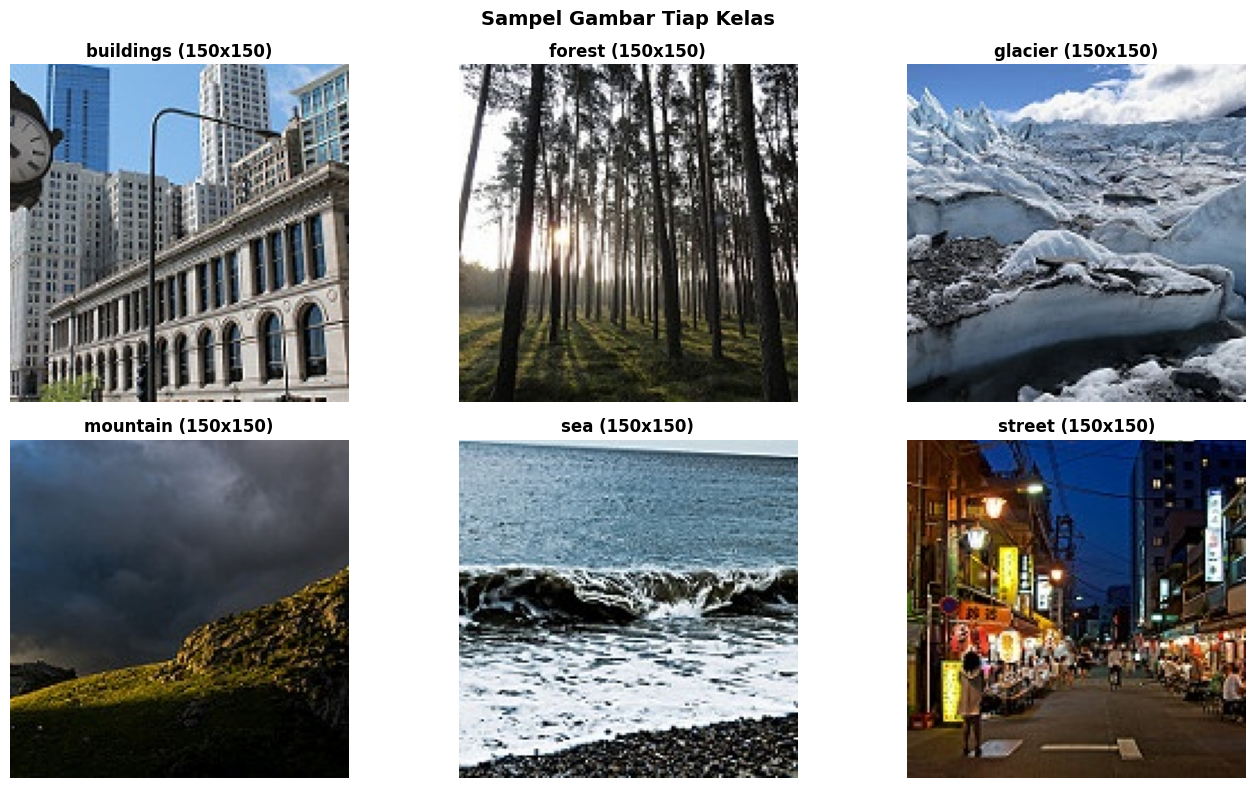

In [6]:
# Tampilkan sampel gambar dari setiap kelas
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, cls in enumerate(classes):
    folder = os.path.join(raw_dir, cls)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    img = Image.open(img_path)
    ax = axes[i // 3][i % 3]
    ax.imshow(img)
    ax.set_title(f'{cls} ({img.size[0]}x{img.size[1]})', fontweight='bold')
    ax.axis('off')
plt.suptitle('Sampel Gambar Tiap Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Data Preprocessing

#### Split Dataset

In [7]:
# Split dataset: 80% train, 10% val, 10% test
split_dir = 'split_dataset'

if not os.path.exists(split_dir) or len(os.listdir(split_dir)) < 3:
    splitfolders.ratio(raw_dir, output=split_dir, seed=42,
                       ratio=(0.80, 0.10, 0.10))

train_dir = os.path.join(split_dir, 'train')
val_dir   = os.path.join(split_dir, 'val')
test_dir  = os.path.join(split_dir, 'test')

print(f'Train: {train_dir}')
print(f'Val  : {val_dir}')
print(f'Test : {test_dir}')

Copying files: 17034 files [00:03, 5523.34 files/s]

Train: split_dataset/train
Val  : split_dataset/val
Test : split_dataset/test


In [8]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Augmentasi hanya pada data training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Normalisasi saja untuk validasi dan test
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True)

val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

NUM_CLASSES = train_gen.num_classes
class_names = list(train_gen.class_indices.keys())
print(f'Jumlah kelas: {NUM_CLASSES}')
print(f'Kelas: {class_names}')

Found 13625 images belonging to 6 classes.
Found 1700 images belonging to 6 classes.
Found 1709 images belonging to 6 classes.
Jumlah kelas: 6
Kelas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Modelling

In [9]:
model = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     5,308,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,701,574 (21.75 MB)

 Trainable params: 5,700,102 (21.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [10]:
# Custom callback: hentikan training jika akurasi sudah tercapai
class AccuracyThreshold(Callback):
    def __init__(self, threshold=0.96):
        super().__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        if logs.get('accuracy', 0) >= self.threshold and logs.get('val_accuracy', 0) >= self.threshold:
            print(f'\nAkurasi target tercapai di epoch {epoch+1}. Training dihentikan.')
            self.model.stop_training = True

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3,
                      min_lr=1e-6, verbose=1),
    AccuracyThreshold(threshold=0.96)
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 109s 233ms/step - accuracy: 0.6162 - loss: 1.1164 - val_accuracy: 0.3871 - val_loss: 1.8094 - learning_rate: 0.0010
Epoch 2/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 89s 209ms/step - accuracy: 0.7149 - loss: 0.7819 - val_accuracy: 0.8282 - val_loss: 0.4860 - learning_rate: 0.0010
Epoch 3/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 89s 208ms/step - accuracy: 0.7586 - loss: 0.6644 - val_accuracy: 0.8094 - val_loss: 0.5566 - learning_rate: 0.0010
Epoch 4/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 89s 208ms/step - accuracy: 0.7852 - loss: 0.5956 - val_accuracy: 0.6212 - val_loss: 1.3976 - learning_rate: 0.0010
Epoch 5/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8097 - loss: 0.5370
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
426/426 ━━━━━━━━━━━━━━━━━━━━ 89s 209ms/step - accuracy: 0.8101 - loss: 0.5322 - val_accuracy: 0.7000 - val_loss: 1.0216 - learning_rate: 0.0010
Epoch 6/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 89s 210ms/step - accuracy: 0.8

## Evaluasi dan Visualisasi

In [12]:
# Evaluasi pada test set
test_loss, test_acc = model.evaluate(test_gen)
print(f'\nTest Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')

54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9052 - loss: 0.2850

Test Loss    : 0.2850
Test Accuracy: 90.52%


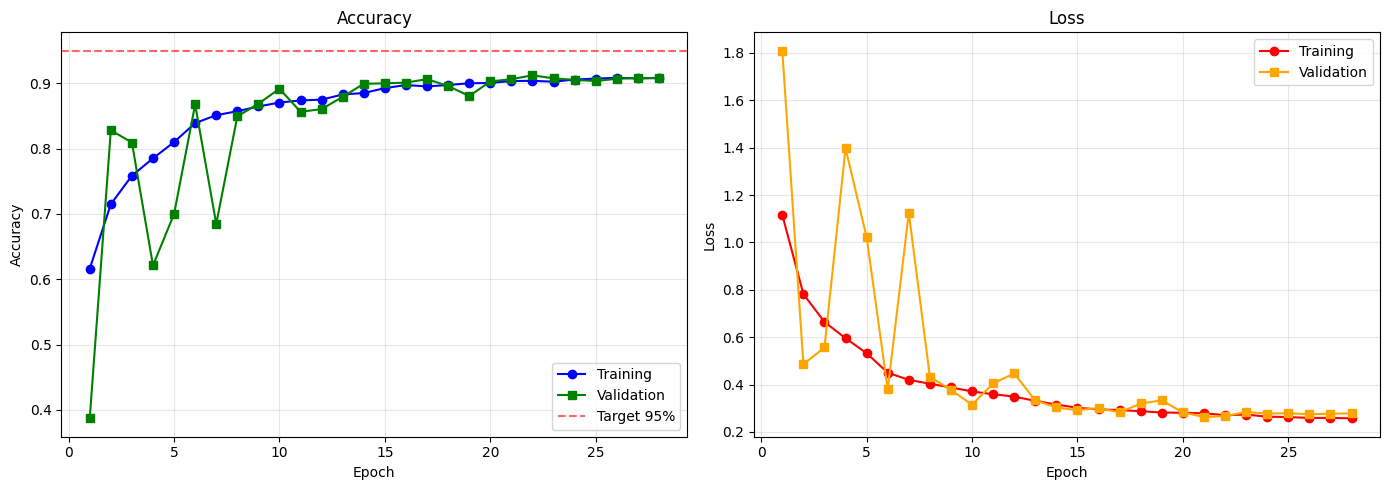

In [13]:
# Plot akurasi dan loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, acc, 'b-o', label='Training')
ax1.plot(epochs, val_acc, 'g-s', label='Validation')
ax1.axhline(y=0.95, color='r', linestyle='--', alpha=0.6, label='Target 95%')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, loss, 'r-o', label='Training')
ax2.plot(epochs, val_loss, 'orange', marker='s', label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Konversi Model

In [14]:
# Buat struktur folder submission
os.makedirs('submission/saved_model', exist_ok=True)
os.makedirs('submission/tflite', exist_ok=True)
os.makedirs('submission/tfjs_model', exist_ok=True)

# 1. SavedModel
try:
    model.export('submission/saved_model')
except Exception:
    model.save('submission/saved_model')
print('SavedModel berhasil disimpan.')

# 2. TF-Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

with open('submission/tflite/label.txt', 'w') as f:
    for name in class_names:
        f.write(name + '\n')
print('TF-Lite model dan label.txt berhasil disimpan.')

# 3. TFJS
try:
    import tensorflowjs as tfjs
    tfjs.converters.save_keras_model(model, 'submission/tfjs_model')
    print('TFJS model berhasil disimpan.')
except Exception:
    model.save('temp_model.h5')
    !tensorflowjs_converter --input_format=keras temp_model.h5 submission/tfjs_model
    os.remove('temp_model.h5') if os.path.exists('temp_model.h5') else None
    print('TFJS model berhasil disimpan via CLI.')

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140304504707152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304504708496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304504712720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304504706768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304504706384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304504706576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304504704656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304504705040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304504701392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304504704272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14030450

/usr/local/lib/python3.13/dist-packages/tensorflowjs/read_weights.py:28: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  np.uint8, np.uint16, np.object, np.bool]


TF-Lite model dan label.txt berhasil disimpan.
/usr/local/lib/python3.13/dist-packages/tensorflowjs/read_weights.py:28: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  np.uint8, np.uint16, np.object, np.bool]
Traceback (most recent call last):
  File "/usr/local/bin/tensorflowjs_converter", line 5, in <module>
    from tensorflowjs.converters.converter import pip_main
  File "/usr/local/lib/python3.13/dist-packages/tensorflowjs/__init__.py", line 21, in <module>
    from tensorflowjs import converters
  File "/usr/local/lib/python3.13/dist-packages/tensorflowjs/converters/__init__.py", line 21, in <module>
    from tensorflowjs.converters.converter import convert
  File "/usr/local/lib/python3.13/dist-packages/tensorflowjs/converters/converter.py", line 35, in <module>
    from tensorflowjs.converters import keras_h5_conversion as conversion
  File "/usr/local/lib/python3.13/dist-packages/tensorflowjs/converters/keras_h5_conversion.py", lin

## Inference

In [ ]:
# Inference menggunakan model TF-Lite
def tflite_predict(model_path, img_path, labels, size=(150,150)):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()
    out = interpreter.get_output_details()

    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize(size)
    arr = np.expand_dims(np.array(img_resized, dtype=np.float32)/255.0, axis=0)

    interpreter.set_tensor(inp[0]['index'], arr)
    interpreter.invoke()
    probs = interpreter.get_tensor(out[0]['index'])[0]
    idx = np.argmax(probs)
    return img, labels[idx], probs[idx]*100

# Ambil sampel dari tiap kelas di test set
samples = []
for cls in class_names:
    d = os.path.join(test_dir, cls)
    samples.append((cls, os.path.join(d, os.listdir(d)[0])))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, (true_label, path) in enumerate(samples):
    img, pred, conf = tflite_predict('submission/tflite/model.tflite', path, class_names)
    ax = axes[i//3][i%3]
    ax.imshow(img)
    color = 'green' if true_label == pred else 'red'
    ax.set_title(f'Aktual: {true_label}\nPrediksi: {pred} ({conf:.1f}%)',
                 color=color, fontweight='bold')
    ax.axis('off')
plt.suptitle('Hasil Inference Model TF-Lite', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Generate requirements.txt
!pipreqs . --force --scan-notebooks --ignore dataset,raw_combined,split_dataset 2>/dev/null || true

if os.path.exists('requirements.txt'):
    shutil.copy2('requirements.txt', 'submission/requirements.txt')

readme = '''# Proyek Klasifikasi Gambar: Intel Image Classification
- Nama: Muhammad Ragil
- Email: mhmmdragilpy
- ID Dicoding: mhmmdragilpy
'''
with open('submission/README.md', 'w') as f:
    f.write(readme)

shutil.make_archive('submission', 'zip', 'submission')
print('submission.zip berhasil dibuat.')